# VidToCode — Dataset Exploratory Data Analysis

This notebook performs EDA on the curated dataset of **36 YouTube programming tutorial videos** across 4 languages × 3 length tiers × 3 videos each.

In [1]:
import os, json, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── dark theme ──
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d',
    'figure.dpi': 120, 'font.size': 11,
})
PALETTE = ['#58a6ff', '#3fb950', '#d29922', '#f85149']

DATA_ROOT = os.path.join(os.pardir, 'data')
LANGUAGES = ['python', 'java', 'cpp', 'javascript']
LENGTHS   = ['short', 'medium', 'long']

rows = []
for lang in LANGUAGES:
    for length in LENGTHS:
        tier_dir = os.path.join(DATA_ROOT, lang, length)
        if not os.path.isdir(tier_dir):
            continue
        for folder in sorted(os.listdir(tier_dir)):
            entry = os.path.join(tier_dir, folder)
            if not os.path.isdir(entry) or folder.startswith('.'):
                continue
            meta_path = os.path.join(entry, 'metadata.json')
            meta = json.load(open(meta_path, encoding='utf-8')) if os.path.exists(meta_path) else {}
            tx_path = os.path.join(entry, 'transcript.txt')
            tx_text = open(tx_path, encoding='utf-8').read() if os.path.exists(tx_path) else ''
            tx_lines = [l.strip() for l in tx_text.splitlines() if l.strip()]
            narration = re.sub(r'\[\d+\.?\d*\]', '', tx_text)
            narr_words = narration.split()
            code_files = [f for f in os.listdir(entry)
                          if f.lower() not in ('metadata.json','transcript.txt','output.txt','.ds_store')
                          and not f.startswith('.')]
            code_text, code_file = '', ''
            for cf in code_files:
                cfp = os.path.join(entry, cf)
                if os.path.isfile(cfp):
                    code_file = cf
                    code_text = open(cfp, encoding='utf-8', errors='ignore').read()
                    break
            code_lines_list = [l for l in code_text.splitlines() if l.strip()]
            out_path = os.path.join(entry, 'output.txt')
            if not os.path.exists(out_path):
                out_path = os.path.join(entry, 'Output.txt')
            out_text = open(out_path, encoding='utf-8').read() if os.path.exists(out_path) else ''
            rows.append({
                'language': lang, 'length_tier': length, 'folder': folder,
                'title': meta.get('title',''), 'channel': meta.get('channel',''),
                'upload_date': meta.get('upload_date',''),
                'duration_sec': meta.get('duration_seconds', 0),
                'view_count': meta.get('view_count', 0),
                'description_len': len(meta.get('description','')),
                'transcript_lines': len(tx_lines),
                'transcript_words': len(narr_words),
                'transcript_chars': len(tx_text),
                'code_file': code_file,
                'code_lines': len(code_lines_list),
                'code_chars': len(code_text),
                'output_lines': len(out_text.splitlines()),
            })

df = pd.DataFrame(rows)
df['duration_min'] = df['duration_sec'] / 60
df['words_per_min'] = df['transcript_words'] / df['duration_min'].replace(0, np.nan)
df['length_tier'] = pd.Categorical(df['length_tier'], categories=LENGTHS, ordered=True)
print(f'Loaded {len(df)} video entries')
df.head()


Loaded 36 video entries


,language,length_tier,folder,title,channel,upload_date,duration_sec,view_count,description_len,transcript_lines,transcript_words,transcript_chars,code_file,code_lines,code_chars,output_lines,duration_min,words_per_min
0,python,short,short_1,Number Guessing Game | Python Example,Portfolio Courses,2022-07-02,144,76019,363,70,419,2697,main.py,14,343,1,2.400000,174.583333
1,python,short,short_2,Python read a file 🔍,Bro Code,2020-12-21,219,125220,513,111,639,4168,test.txt,3,68,3,3.650000,175.068493
2,python,short,short_3,Python: BubbleSort sorting algorithm,Programming and Math Tutorials,2015-02-19,166,111170,543,69,544,3215,main.py,9,325,1,2.766667,196.626506
3,python,medium,medium_1,How To Code A To Do List App In Python | Progr...,Brainrot Academy,2023-11-06,856,57875,1548,366,2877,17254,main.py,46,1316,10,14.266667,201.658879
4,python,medium,medium_2,Python Tutorial: Using Try/Except Blocks for E...,Corey Schafer,2015-11-13,634,788537,1296,258,2009,12142,test_file.txt,1,19,3,10.566667,190.126183


## 1 · High-Level Summary

In [2]:
summary = df.groupby('language').agg(
    videos=('folder','count'), total_words=('transcript_words','sum'),
    mean_words=('transcript_words','mean'), mean_dur_min=('duration_min','mean'),
    total_views=('view_count','sum'), mean_code_lines=('code_lines','mean'),
).round(1)
summary.style.format({'total_views':'{:,.0f}','total_words':'{:,.0f}'}).set_caption('Per-Language Summary')


,videos,total_words,mean_words,mean_dur_min,total_views,mean_code_lines
language,,,,,,
cpp,9,"18,404",2044.900000,12.500000,"800,182",47.400000
java,9,"18,592",2065.800000,12.200000,"566,760",52.400000
javascript,9,"15,941",1771.200000,11.500000,"259,719",22.800000
python,9,"17,549",1949.900000,11.800000,"1,774,515",28.700000


## 2 · Video Duration Distribution

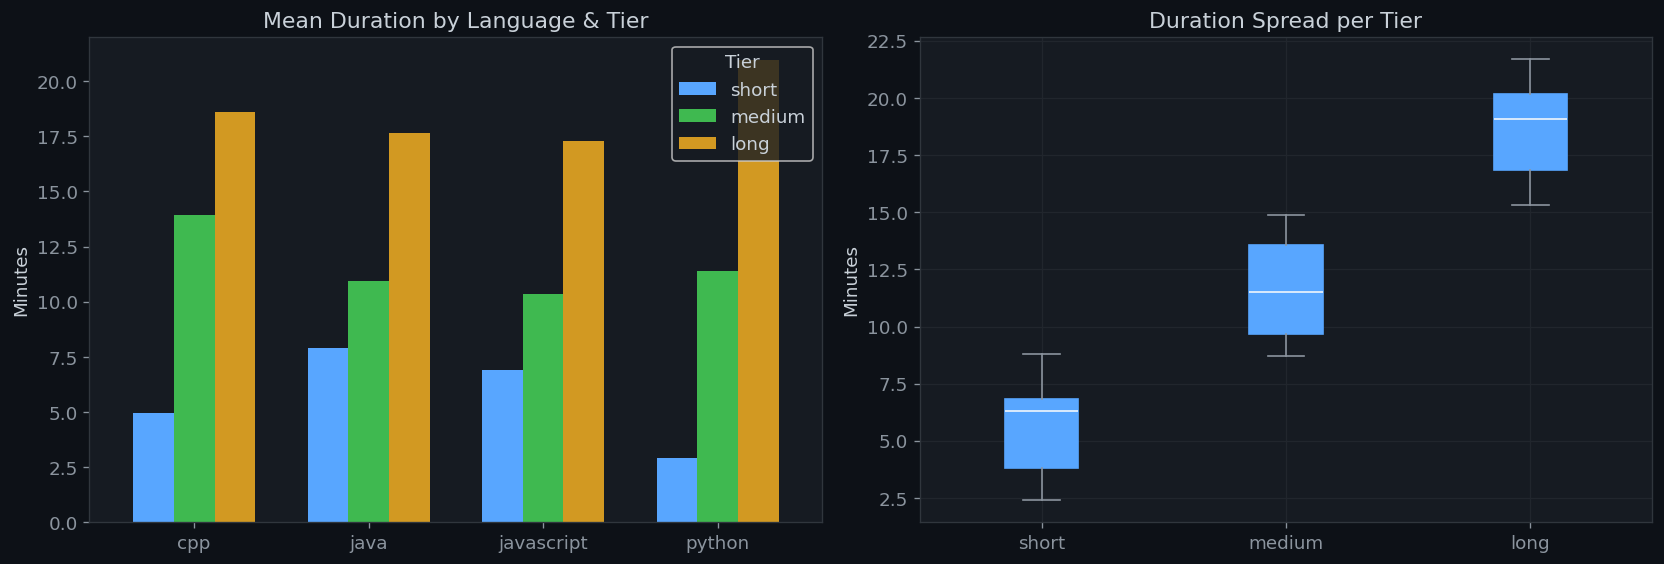

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_dur = df.pivot_table('duration_min', index='language', columns='length_tier', aggfunc='mean')
pivot_dur.plot.bar(ax=axes[0], color=PALETTE[:3], edgecolor='none', width=0.7)
axes[0].set_title('Mean Duration by Language & Tier'); axes[0].set_ylabel('Minutes')
axes[0].set_xlabel(''); axes[0].legend(title='Tier'); axes[0].tick_params(axis='x', rotation=0)
bp = df.boxplot(column='duration_min', by='length_tier', ax=axes[1],
    patch_artist=True, return_type='dict',
    boxprops=dict(facecolor='#58a6ff',color='#58a6ff'),
    medianprops=dict(color='#f0f6fc'), whiskerprops=dict(color='#8b949e'),
    capprops=dict(color='#8b949e'), flierprops=dict(markeredgecolor='#8b949e'))
axes[1].set_title('Duration Spread per Tier'); axes[1].set_xlabel(''); axes[1].set_ylabel('Minutes')
fig.suptitle(''); plt.tight_layout(); plt.show()


## 3 · Transcript Word Counts

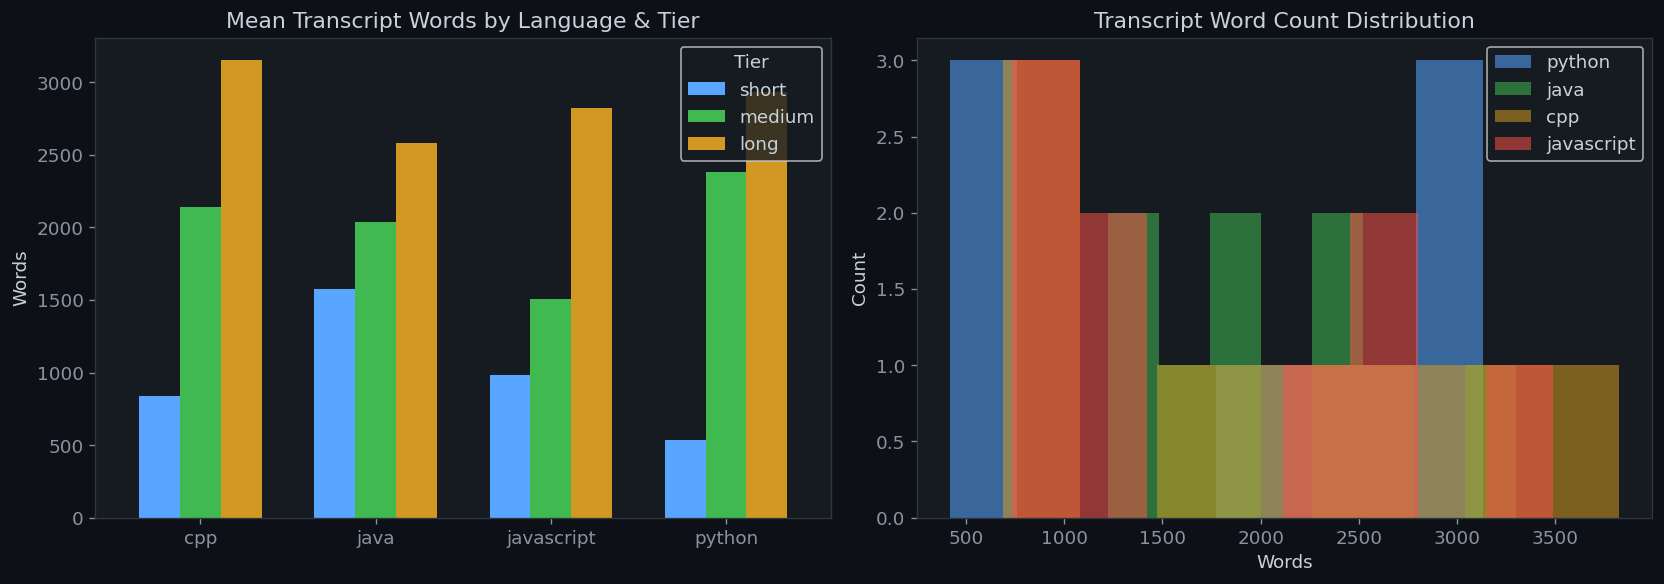

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_w = df.pivot_table('transcript_words', index='language', columns='length_tier', aggfunc='mean')
pivot_w.plot.bar(ax=axes[0], color=PALETTE[:3], edgecolor='none', width=0.7)
axes[0].set_title('Mean Transcript Words by Language & Tier')
axes[0].set_ylabel('Words'); axes[0].set_xlabel('')
axes[0].legend(title='Tier'); axes[0].tick_params(axis='x', rotation=0)
for i, lang in enumerate(LANGUAGES):
    axes[1].hist(df[df.language==lang]['transcript_words'], bins=8, alpha=0.55,
                 label=lang, color=PALETTE[i], edgecolor='none')
axes[1].set_title('Transcript Word Count Distribution')
axes[1].set_xlabel('Words'); axes[1].set_ylabel('Count'); axes[1].legend()
plt.tight_layout(); plt.show()


## 4 · Speaking Rate (Words per Minute)

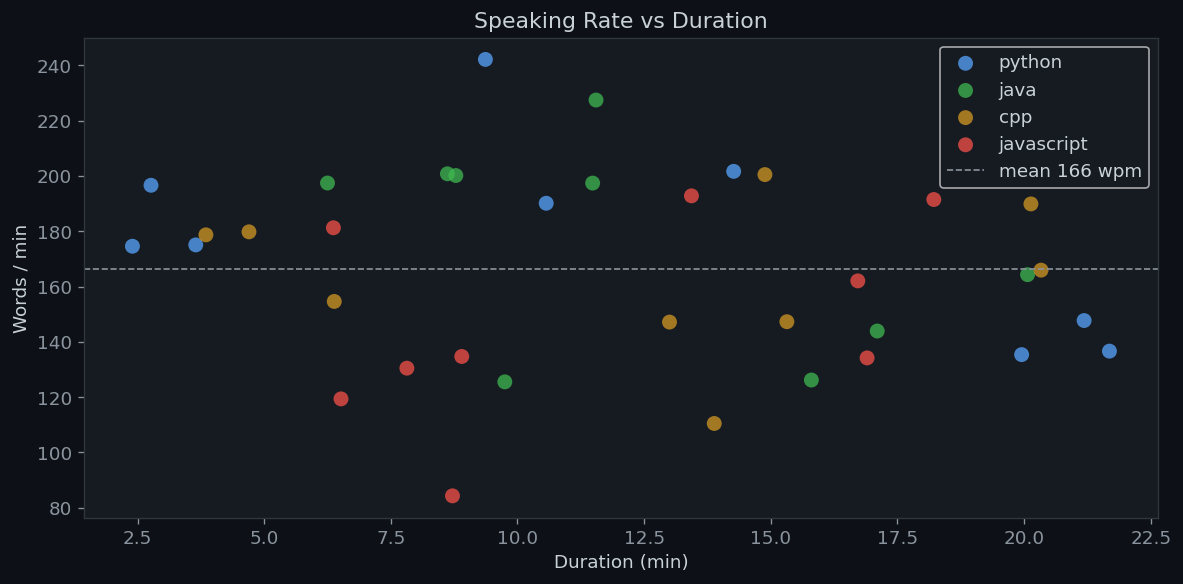

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, lang in enumerate(LANGUAGES):
    sub = df[df.language == lang]
    ax.scatter(sub['duration_min'], sub['words_per_min'], s=80, alpha=.75,
               color=PALETTE[i], label=lang, edgecolors='none')
mean_wpm = df['words_per_min'].mean()
ax.axhline(mean_wpm, ls='--', color='#8b949e', lw=1, label=f'mean {mean_wpm:.0f} wpm')
ax.set_xlabel('Duration (min)'); ax.set_ylabel('Words / min')
ax.set_title('Speaking Rate vs Duration'); ax.legend()
plt.tight_layout(); plt.show()


## 5 · Source Code Complexity

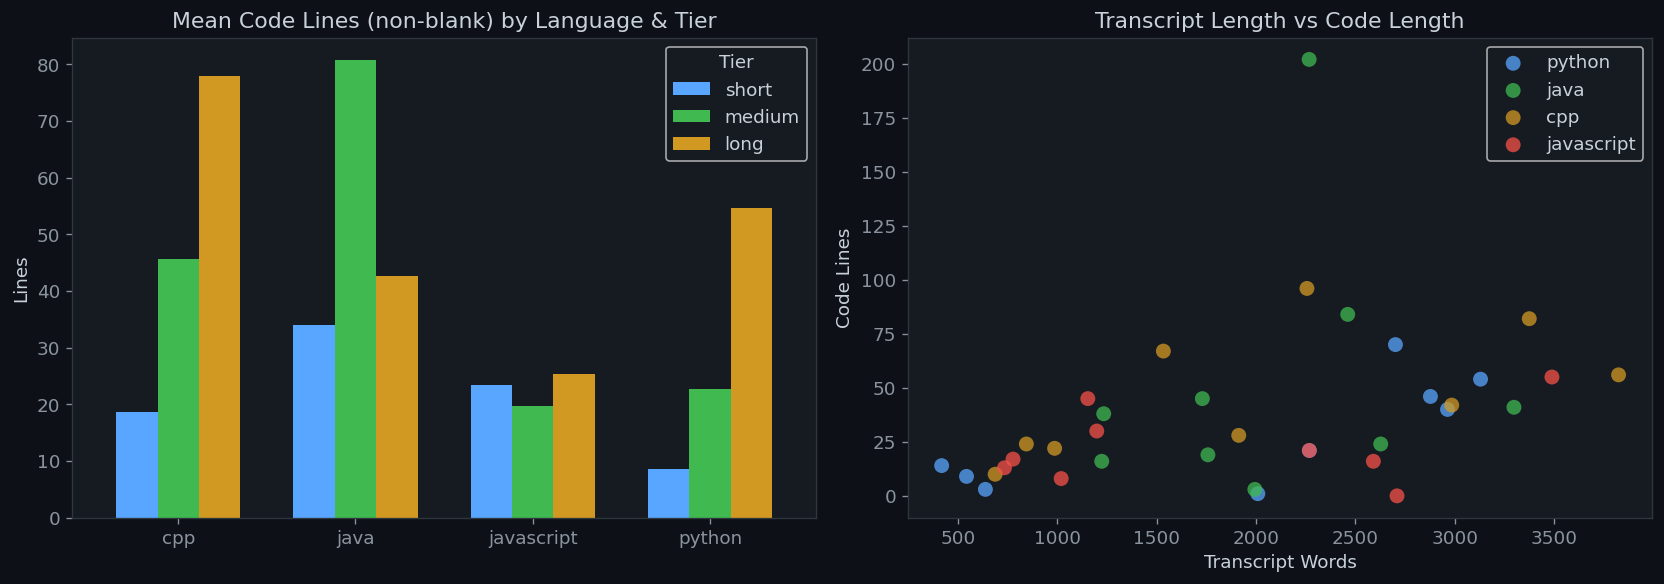

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_c = df.pivot_table('code_lines', index='language', columns='length_tier', aggfunc='mean')
pivot_c.plot.bar(ax=axes[0], color=PALETTE[:3], edgecolor='none', width=0.7)
axes[0].set_title('Mean Code Lines (non-blank) by Language & Tier')
axes[0].set_ylabel('Lines'); axes[0].set_xlabel('')
axes[0].legend(title='Tier'); axes[0].tick_params(axis='x', rotation=0)
for i, lang in enumerate(LANGUAGES):
    sub = df[df.language == lang]
    axes[1].scatter(sub['transcript_words'], sub['code_lines'], s=80, alpha=.75,
                    color=PALETTE[i], label=lang, edgecolors='none')
axes[1].set_xlabel('Transcript Words'); axes[1].set_ylabel('Code Lines')
axes[1].set_title('Transcript Length vs Code Length'); axes[1].legend()
plt.tight_layout(); plt.show()


## 6 · YouTube View Counts

/var/folders/yd/ryrz1z9x75g4bbww6dny67sc0000gn/T/ipykernel_22059/3979538577.py:14: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  axes[1].invert_yaxis(); plt.tight_layout(); plt.show()
/Users/ahmed/Desktop/VidToCode/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


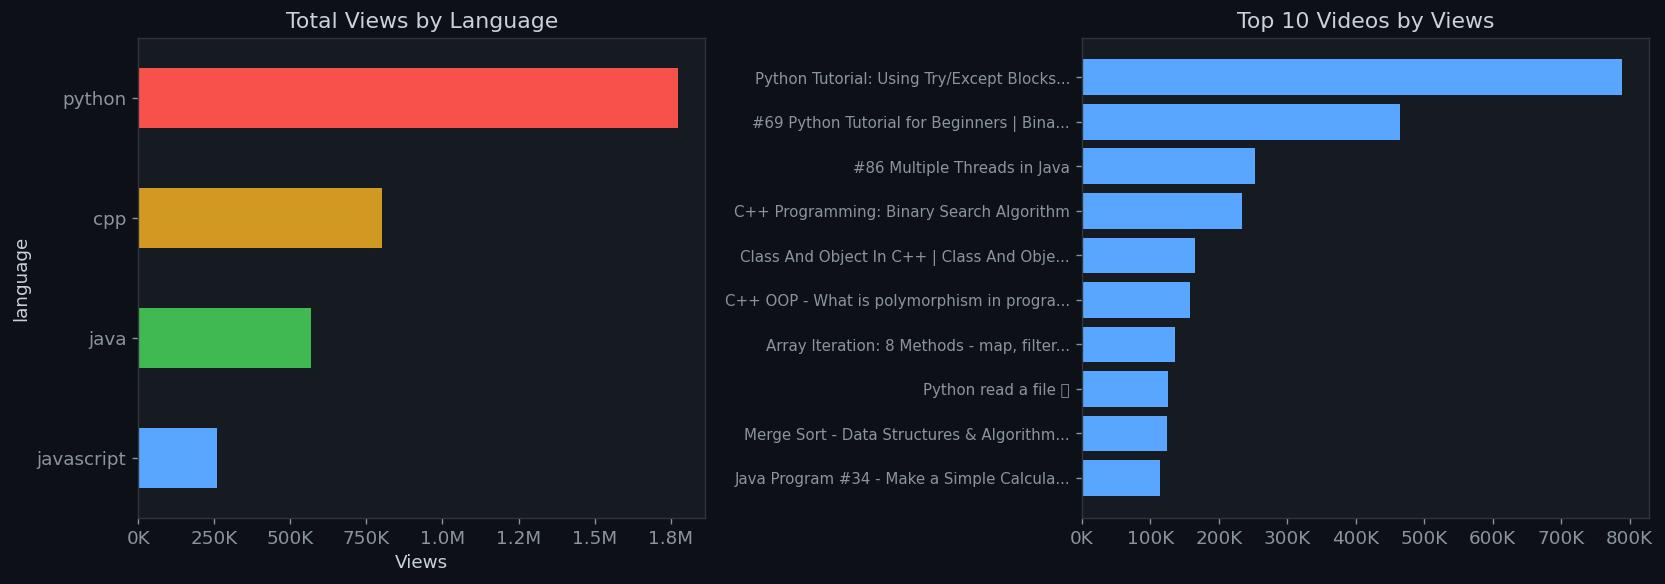

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df.groupby('language')['view_count'].sum().sort_values()
vc.plot.barh(ax=axes[0], color=PALETTE[:4], edgecolor='none')
axes[0].set_title('Total Views by Language'); axes[0].set_xlabel('Views')
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x>=1e6 else f'{x/1e3:.0f}K'))
top = df.nlargest(10, 'view_count')[['title','language','view_count']].reset_index(drop=True)
axes[1].barh(range(len(top)), top['view_count'], color=PALETTE[0], edgecolor='none')
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels([t[:40]+'...' if len(t)>40 else t for t in top['title']], fontsize=9)
axes[1].set_title('Top 10 Videos by Views')
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x>=1e6 else f'{x/1e3:.0f}K'))
axes[1].invert_yaxis(); plt.tight_layout(); plt.show()


## 7 · Channel Diversity

In [8]:
ch = df.groupby('channel').agg(
    videos=('folder','count'),
    languages=('language', lambda x: ', '.join(sorted(x.unique()))),
    mean_views=('view_count','mean'),
).sort_values('videos', ascending=False)
ch.style.format({'mean_views':'{:,.0f}'}).set_caption('Channels in the Dataset')


,videos,languages,mean_views
channel,,,
Bro Code,4,"cpp, java, javascript, python","57,984"
Telusko,2,"java, python","358,616"
Portfolio Courses,2,"cpp, python","52,530"
355Code,1,javascript,581
LetCode with Koushik,1,javascript,"1,341"
codebasics,1,python,"124,087"
Wrt Tech,1,java,"2,228"
United Top Tech,1,java,587
The Normie Programmer,1,javascript,"1,776"


## 8 · Upload Year Timeline

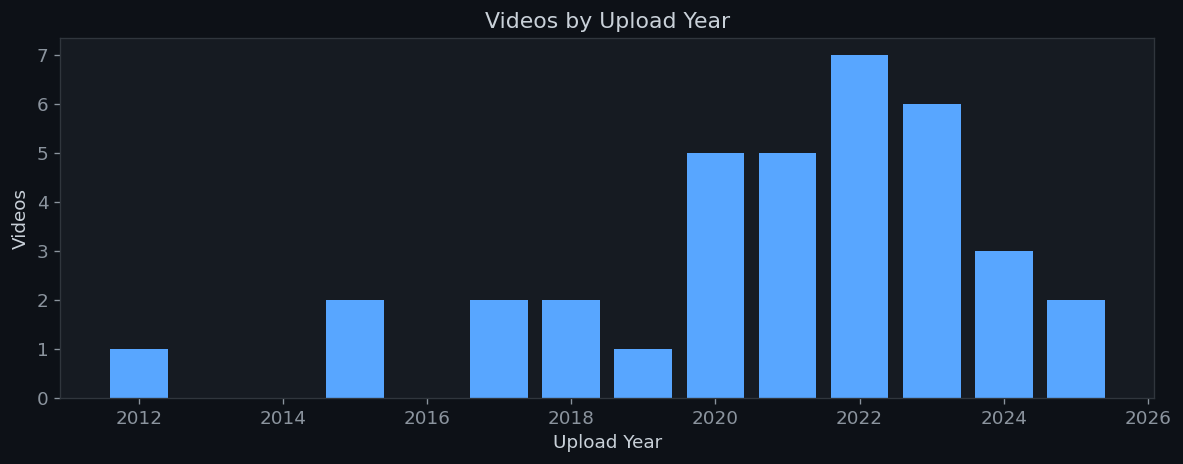

In [9]:
df['upload_year'] = pd.to_datetime(df['upload_date'], errors='coerce').dt.year
fig, ax = plt.subplots(figsize=(10, 4))
yr = df.groupby('upload_year').size()
ax.bar(yr.index.astype(int), yr.values, color='#58a6ff', edgecolor='none')
ax.set_xlabel('Upload Year'); ax.set_ylabel('Videos')
ax.set_title('Videos by Upload Year')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout(); plt.show()


## 9 · Correlation Matrix

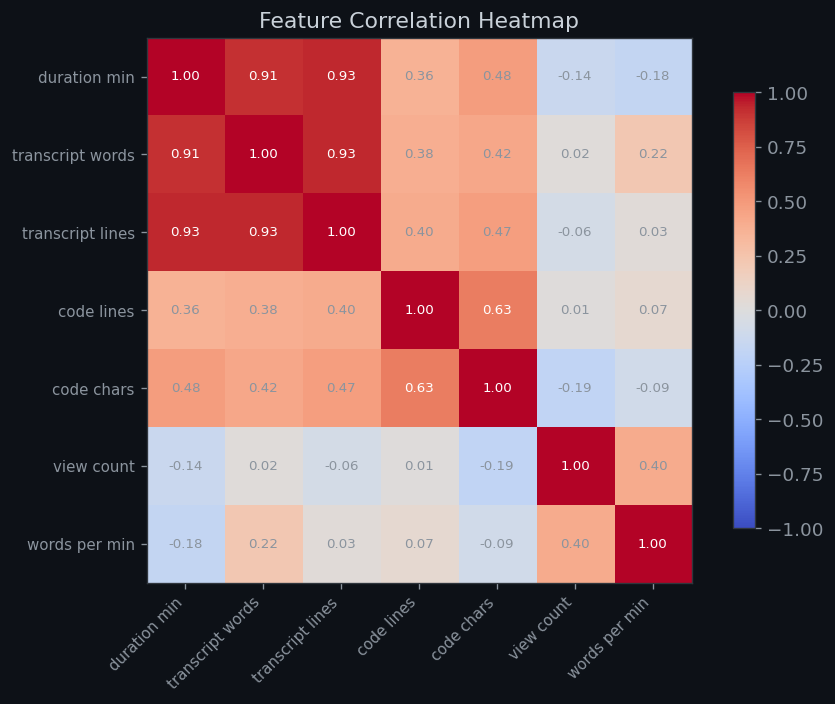

In [10]:
num_cols = ['duration_min','transcript_words','transcript_lines',
            'code_lines','code_chars','view_count','words_per_min']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels([c.replace('_',' ') for c in num_cols], rotation=45, ha='right', fontsize=9)
ax.set_yticklabels([c.replace('_',' ') for c in num_cols], fontsize=9)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.values[i,j])>.5 else '#8b949e', fontsize=8)
fig.colorbar(im, ax=ax, shrink=.8); ax.set_title('Feature Correlation Heatmap')
plt.tight_layout(); plt.show()


## 10 · Full Descriptive Statistics

In [11]:
df[['duration_min','transcript_words','transcript_lines',
    'code_lines','code_chars','view_count','words_per_min']].describe().round(1)


,duration_min,transcript_words,transcript_lines,code_lines,code_chars,view_count,words_per_min
count,36.0,36.0,36.0,36.0,36.0,36.0,36.0
mean,12.0,1957.9,290.4,37.8,886.3,94477.1,166.3
std,5.8,966.9,145.7,37.6,778.9,151861.1,34.8
min,2.4,419.0,69.0,0.0,0.0,14.0,84.3
25%,7.5,1120.5,147.5,15.5,338.5,2115.0,136.3
50%,11.5,2001.5,284.5,26.0,748.0,48972.0,170.3
75%,16.8,2703.0,399.0,48.0,1178.2,117032.5,193.8
max,21.7,3823.0,598.0,202.0,3378.0,788537.0,242.1


## 11 · Complete Dataset Table

In [12]:
display_cols = ['language','length_tier','title','channel','duration_min',
                'transcript_words','code_lines','view_count']
df[display_cols].sort_values(['language','length_tier']).style.format(
    {'duration_min':'{:.1f}','view_count':'{:,.0f}'}).set_caption('All 36 Video Entries')


,language,length_tier,title,channel,duration_min,transcript_words,code_lines,view_count
18,cpp,short,Number Guessing Game | C++ Example,Portfolio Courses,6.4,987,22,"29,042"
19,cpp,short,C++ Programming Tutorial 6 - Variable Declaration and Initialization,Caleb Curry,3.9,688,10,"103,353"
20,cpp,short,Understanding Linear Search Algorithm 👨‍💻🚀|| Explanation + Code in C++ || Born2Code,Born2Code,4.7,845,24,137
21,cpp,medium,Class And Object In C++ | Class And Object With Examples In C++,CppNuts,13.0,1913,28,"164,581"
22,cpp,medium,C++ Banking program for beginners 💰,Bro Code,13.9,1534,67,"33,792"
23,cpp,medium,C++ Programming: Binary Search Algorithm,ReelLearning,14.9,2984,42,"233,763"
24,cpp,long,Tic Tac Toe Game in C++,Kenny Yip Coding,20.3,3374,82,"31,053"
25,cpp,long,Quick Sort Algorithm in C++ Programming | (C++ Program) | Part - 2 | Sorting Algorithms - DSA,Simple Snippets,20.1,3823,56,"46,655"
26,cpp,long,C++ OOP - What is polymorphism in programming? (simple example),CodeBeauty,15.3,2256,96,"157,806"
9,java,short,Arrays | Java | Tutorial 12,Giraffe Academy,8.8,1758,19,"51,289"
